# Tutorial 4: GRN Analysis

After training, we can extract and analyze the learned Gene Regulatory Network. The model learns two regulatory matrices:

- **E1 (TF→Region)**: Which TFs bind to which regulatory regions
- **E2 (Region→Gene)**: Which regions regulate which genes

This tutorial shows how to extract these matrices and find key regulatory relationships.

## Setup

In [1]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

In [2]:
data_dir = "./data/MM_lines_results/"

# Load trained model and data
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

print(f"Model: {len(model.tf_names)} TFs, {len(model.gene_names)} genes")

/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/groups/vib.ai/stein.aerts/lmahieu/software/miniconda3/envs/deepscenic-dev/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
deepscenic.tl - INFO - Loaded model from ./data/MM_lines_results/checkpoints/deepscenic_model.pt: 12156 genes, 1462 TFs, 281820 regions
deepscenic.io - INFO - Loaded data/MM_lines_results/preprocessed_data.h5mu: 936 cells, 12156 genes, 281820 regions


Model: 1462 TFs, 12156 genes


Based on the SCENIC+ paper, we expect certain TFs to be active in specific cell states:

| Cell State | Expected Active TFs |
|------------|-------------------|
| **MEL** | SOX10, MITF, TFAP2A, RUNX3 |
| **MES** | JUN, NFIB, ZEB1 |
| **INT** | SOX6, EGR3, ETV4 |

## Extract GRN

The GRN consists of two matrices:

- **E1 (TF->Region)**: TF binding potential to regulatory regions
- **E2 (Region->Gene)**: Region regulatory effect on genes

The combined GRN is E1 @ E2, giving TF->Gene regulatory weights.

In [3]:
# Extract the full GRN as a DataFrame
# Returns dict with 'E1', 'E2' DataFrames
grn = ds.tl.extract_grn(model)

print(f"E1 (TF→Region): {grn['E1'].shape}")
print(f"E2 (Region→Gene): {grn['E2'].shape}")

E1 (TF→Region): (281820, 1462)
E2 (Region→Gene): (3253274, 3)


## Find TF Targets

Get the target genes for a specific TF, ranked by regulatory weight:

In [4]:
# Find targets of a TF
# Uses Otsu thresholding to identify significant links
targets = ds.tl.get_tf_targets(model, tf_name="SOX10", top_k=20)
targets

deepscenic.tl._grn - INFO - TF 'SOX10': using Otsu E1 threshold = 0.5050


,tf,region,E1_weight,gene,E2_weight,combined_weight
22809,SOX10,chr11:89168287-89168787,2.357260,TYR,0.013553,0.031949
32655,SOX10,chr12:56082949-56083449,2.898317,PMEL,0.009657,0.027990
118699,SOX10,chr21:45831903-45832403,0.926917,S100B,0.029725,0.027553
75188,SOX10,chr19:17479249-17479749,0.830824,GDF15,0.024274,0.020168
217109,SOX10,chrX:46739687-46740187,0.803055,TIMP1,0.024684,0.019822
77427,SOX10,chr19:36482815-36483315,0.540835,GAPDHS,0.035791,0.019357
40438,SOX10,chr14:106419269-106419769,0.682307,CRIP2,0.026338,0.017971
97097,SOX10,chr1:210188176-210188676,-1.205609,G0S2,0.014896,-0.017958
32620,SOX10,chr12:56081505-56082005,1.821594,PMEL,0.009839,0.017922
89798,SOX10,chr1:152996859-152997359,0.655855,S100A1,0.026368,0.017293


SOX10 is a master regulator of the melanocytic lineage. Its target genes should include Melanocyte differentiation genes.  

## Find Gene Regulators

Get the TFs that regulate a specific gene:

In [5]:
# Find regulators of a gene
regulators = ds.tl.get_gene_regulators(model, gene_name="MITF", top_k=10)
regulators

deepscenic.tl._grn - INFO - Gene 'MITF': using per-TF Otsu thresholds


,gene,tf,region,E1_weight,E2_weight,combined_weight
62878,MITF,MITF,chr3:69926370-69926870,2.881521,0.004398,0.012672
62957,MITF,PIR,chr3:69926370-69926870,2.490975,0.004398,0.010954
63040,MITF,SOX10,chr3:69926370-69926870,2.222245,0.004398,0.009773
62588,MITF,ANXA1,chr3:69926370-69926870,-1.735487,0.004398,-0.007632
62808,MITF,ID2,chr3:69926370-69926870,1.623141,0.004398,0.007138
62893,MITF,MXI1,chr3:69926370-69926870,1.488243,0.004398,0.006545
63011,MITF,RUNX3,chr3:69926370-69926870,1.328265,0.004398,0.005841
63167,MITF,ZCCHC17,chr3:69926370-69926870,1.241445,0.004398,0.005459
44755,MITF,MITF,chr3:69676053-69676553,1.952126,0.002415,0.004714
62965,MITF,POLR3G,chr3:69926370-69926870,1.020067,0.004398,0.004486


## Visualize GRN Heatmaps

The combined GRN heatmap shows the TF→gene regulatory weights (E1 @ E2), z-score normalized
per TF to highlight gene-specific patterns. For cell-type specific visualization, see the
cell-type aware workflow below.

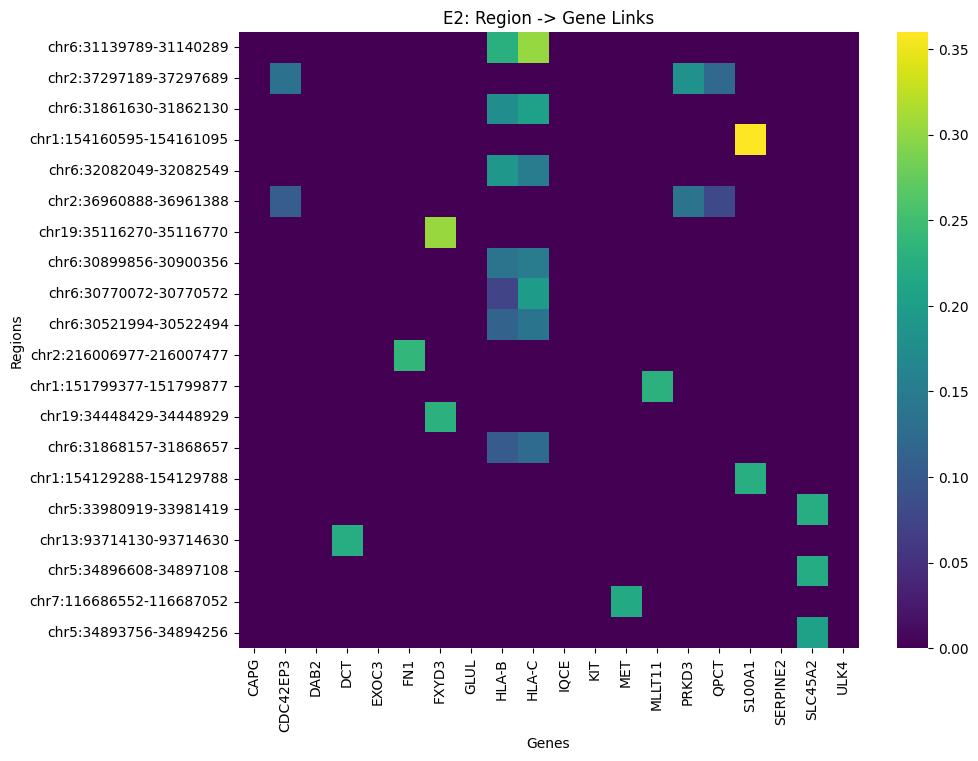

In [6]:
# E2 heatmap (Region->Gene)
ds.pl.heatmap_e2(model, top_k=20)

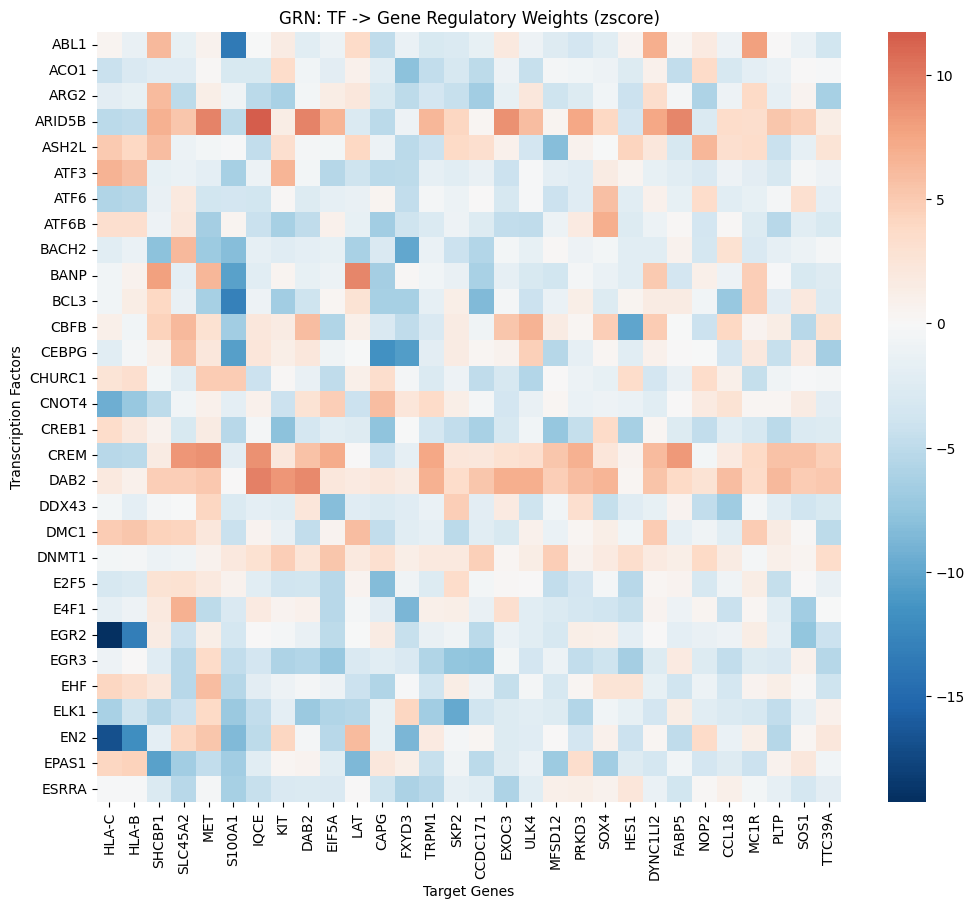

In [7]:
# Combined GRN heatmap (TF->Gene), z-score normalized per TF
ds.pl.heatmap_grn(model, top_k=30)

## Cell-Type Aware GRN Analysis

The basic GRN extraction averages across all cells. For cell-type-specific regulatory networks, use the cell-type aware workflow:

1. Compute enhancer activity per cell type
2. Identify active enhancers using Otsu thresholding
3. Compute TF activity scores weighted by active enhancers
4. Identify key TFs per cell type
5. Build focused GRN for key TFs

In [8]:
# Step 1: Compute mean enhancer activity per cell type
enh_activity = ds.tl.compute_celltype_enhancer_activity(
    model, mdata, celltype_key="cell_state"
)
print(f"Enhancer activity: {enh_activity.shape}")  # (n_regions, n_celltypes)

Extracting embeddings:  25%|██▌       | 1/4 [00:00<00:02,  1.10it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 34.40 GiB. GPU 0 has a total capacity of 79.25 GiB of which 6.98 GiB is free. Including non-PyTorch memory, this process has 72.26 GiB memory in use. Of the allocated memory 37.85 GiB is allocated by PyTorch, and 33.92 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [9]:
# Step 2: Identify active enhancers per cell type (Otsu threshold)
active_enhancers = ds.tl.identify_active_enhancers(enh_activity)

for ct, regions in active_enhancers.items():
    print(f"  {ct}: {len(regions)} active enhancers")

NameError: name 'enh_activity' is not defined

In [ ]:
# Step 3: Visualize enhancer overlap across cell types
ds.pl.upset_active_enhancers(active_enhancers)

In [ ]:
# Step 4: Compute TF activity scores weighted by active enhancers
tf_scores = ds.tl.compute_tf_activity_scores(
    model, mdata, celltype_key="cell_state", active_enhancers=active_enhancers
)

# Visualize as heatmap
ds.pl.heatmap_celltype_activity(tf_scores, top_k=50)

### Interpreting the TF Activity Clustermap

In the clustermap above, look for:

1. **Cell-state-specific TF clusters**: TFs that are highly active in one state but not others
2. **Master regulators**: SOX10 and MITF should cluster together and show high activity in MEL cells
3. **MES regulators**: JUN-family TFs and ZEB1 should be active in MES cells
4. **Intermediate regulators**: If visible, INT cells may show a mix or have their own specific TFs

The hierarchical clustering on the left groups TFs by similar activity patterns across cell states, revealing the regulatory programs that define each phenotype.

In [ ]:
# Step 5: Identify key TFs (union across cell types)
key_tfs = ds.tl.identify_key_tfs(tf_scores)
print(f"Identified {len(key_tfs)} key TFs: {key_tfs[:10]}...")

In [ ]:
# Step 6: Build focused GRN for key TFs only
focused_grn = ds.tl.build_grn_for_tfs(model, key_tfs)
print(f"Focused GRN: {len(focused_grn)} edges")
focused_grn.head(10)

## Network Visualization

Network graphs show the GRN structure as connected nodes.

In [ ]:
# Visualize full GRN as network
ds.pl.network_grn(model, top_k=50)

In [ ]:
# TF-centric network: show targets of a specific TF
ds.pl.network_tf_targets(model, tf="SOX10", top_k=20)

In [ ]:
# Gene-centric network: show regulators of a specific gene
ds.pl.network_gene_regulators(model, gene="MITF", top_k=10)

## Next Steps

Now that you've extracted and visualized the GRN:

- Simulate perturbation experiments: {doc}`05_perturbation_analysis`
- Explore advanced genomic visualizations: {doc}`06_advanced_visualization`